In [6]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-05 00:23:04.431814: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-05 00:23:04.569060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [3]:
nbatch = 10

In [36]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        g = np.load(geo)
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        
        return g,pre,vel,velx,vely
    
    x_tensor, p_tensor, v_tensor, vx_tensor, vy_tensor= tf.numpy_function(load_array,
    [g_path,p_path,v_path, vx_path,vy_path],             [tf.float64,tf.float64,tf.float64,tf.float64,tf.float64])

    x_tensor.set_shape([x_tensor.shape[0],x_tensor.shape[1],x_tensor.shape[2]])
    p_tensor.set_shape([p_tensor.shape[0],p_tensor.shape[1],p_tensor.shape[2]])
    v_tensor.set_shape([v_tensor.shape[0],v_tensor.shape[1],v_tensor.shape[2]])
    vx_tensor.set_shape([vx_tensor.shape[0],vx_tensor.shape[1],vx_tensor.shape[2]])
    vy_tensor.set_shape([vy_tensor.shape[0],vy_tensor.shape[1],vy_tensor.shape[2]])
    
    return x_tensor, (p_tensor, v_tensor, vx_tensor, vy_tensor) 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files, v_files, vx_files, vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)


In [37]:
xtrue=[]
ytrue=[]
for x,y in train_ds:
    xtrue.append(x)
    ytrue.append(y)

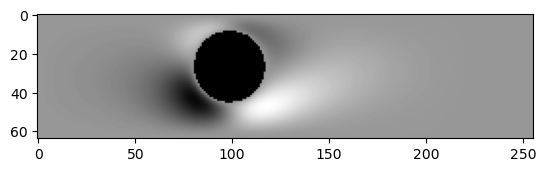

In [47]:
plt.imshow(ytrue[20][3][3],cmap='gray')

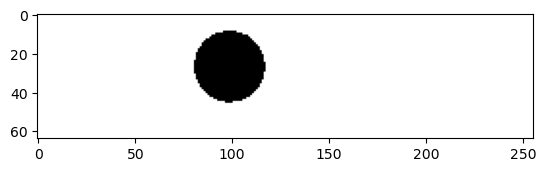

In [44]:
plt.imshow(xtrue[20][3],cmap='gray')

In [5]:
num_epochs    =50
patience      =5     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_name    ="U-Net"
save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

#number_of_filters = [64, 128, 256, 512, 1024]
number_of_filters = [32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
#optimizer = RMSprop(learning_rate=LR)
optimizer = Adam(learning_rate=LR)
#optimizer = SGD(learning_rate=LR, momentum=0.9)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [6]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def biLSTM(x,units=128):
    _, h, w, c = x.shape #Flatten spatial dimensions for LSTM
    x_reshaped = layers.Reshape((h*w, c))(x)
    x_bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(x_reshaped) 
    x_bilstm = layers.Reshape((h, w, units*2))(x_bilstm)
    return x_bilstm

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [7]:
# number_of_filters = [32,64,128,256,512]
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])

    conv5 = conv_block(number_of_filters[4],down_block4)
   
 
    up6=decoder(conv5,conv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,conv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,conv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,conv1,number_of_filters[0],transpose='yes')

    p_out = Conv2D(1, (1, 1), activation=f_activation_last,name='p_output',padding="same")(up9)
    v_out = Conv2D(1, (1, 1), activation=f_activation_last,name='v_output',padding="same")(up9)
    vx_out = Conv2D(1, (1, 1), activation=f_activation_last,name='vx_output',padding="same")(up9)
    vy_out = Conv2D(1, (1, 1), activation=f_activation_last,name='vy_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[p_out,v_out,vx_out,vy_out,],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
                  
              loss = {  'p_output': 'mean_squared_error',
                        'v_output': 'mean_squared_error' ,
                        'vx_output': 'mean_squared_error', 
                        'vy_output': 'mean_squared_error'},
                        
              
              metrics={ 
                        'p_output': ['mae'], 
                        'v_output': ['mae'],
                        'vx_output': ['mae'],
                        'vy_output': ['mae'] 
                      
                      })
   

    return model  

In [8]:
M=make_model()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,763,460 (29.62 MB)

 Trainable params: 7,761,540 (29.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

Starting trainig
Epoch 1/50


I0000 00:00:1748924628.529764   29164 service.cc:146] XLA service 0x76c6d8006550 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748924628.529797   29164 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1748924628.555750   29164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 244ms/step - loss: 0.1548 - p_output_loss: 0.0774 - p_output_mae: 0.1484 - v_output_loss: 0.0434 - v_output_mae: 0.1490 - vx_output_loss: 0.0177 - vx_output_mae: 0.0914 - vy_output_loss: 0.0162 - vy_output_mae: 0.0835 - val_loss: 0.1940 - val_p_output_loss: 0.1392 - val_p_output_mae: 0.3660 - val_v_output_loss: 0.0414 - val_v_output_mae: 0.1479 - val_vx_output_loss: 0.0068 - val_vx_output_mae: 0.0657 - val_vy_output_loss: 0.0066 - val_vy_output_mae: 0.0643
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - loss: 0.0460 - p_output_loss: 0.0019 - p_output_mae: 0.0331 - v_output_loss: 0.0420 - v_output_mae: 0.1478 - vx_output_loss: 9.8187e-04 - vx_output_mae: 0.0202 - vy_output_loss: 0.0011 - vy_output_mae: 0.0204 - val_loss: 0.0962 - val_p_output_loss: 0.0398 - val_p_output_mae: 0.1215 - val_v_output_loss: 0.0414 - val_v_output_mae: 0.1479 - val_vx_output_loss: 0.0072 - val_vx_output_mae: 0.0641 - val_vy_output_loss: 0.0079 - val_vy_output_mae: 0.06

In [10]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0020 - p_output_loss: 8.9398e-04 - p_output_mae: 0.0237 - v_output_loss: 4.7651e-04 - v_output_mae: 0.0144 - vx_output_loss: 2.5078e-04 - vx_output_mae: 0.0121 - vy_output_loss: 3.9063e-04 - vy_output_mae: 0.0127
Evaluation results:
loss: 0.0020
compile_metrics: 0.0009
p_output_loss: 0.0004
v_output_loss: 0.0002
vx_output_loss: 0.0004
vy_output_loss: 0.0237


In [21]:
ypred=[]
ytrue=[]
for x,y in test_ds:
    ypred.append(M.predict(x))
    ytrue.append(y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/

2025-06-03 00:54:21.339144: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


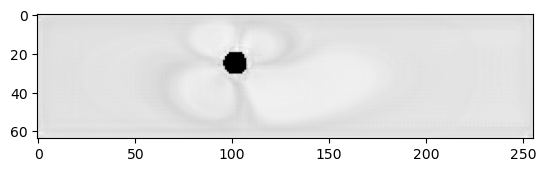

In [30]:
plt.imshow(ypred[20][0][1],cmap='gray')

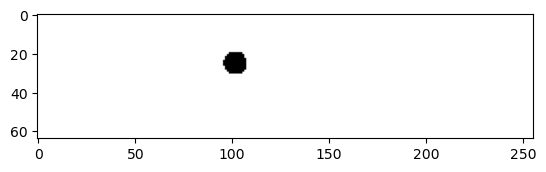

In [29]:
plt.imshow(ytrue[20][0][1],cmap='gray')

In [ ]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

In [ ]:
'''
k=1
for g,y in train_ds:
   for i in range(len(y)):
       print(i,y[i].shape)
   print('*****',k)
   k+=1 
'''  

In [ ]:
def plotting():
    N = random.randint(0, len(xtrue)-1)
    M = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[M][N][:,:,i]- ypred[M][N][:,:,i]))

            axes[i,0].imshow(ypred[M][N][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[M][N][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

In [ ]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [ ]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

In [ ]:
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.grid(True)
plt.show()

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.grid(True)
plt.show() 

In [4]:
import cv2
import numpy as np
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot            as plt

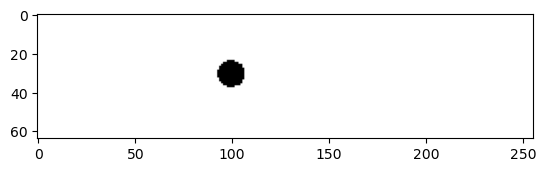

In [ ]:
x=np.load('G_Masked/test/geo_01701.npy')
plt.imshow(x,cmap='gray')

In [11]:
### method for reading image    
def get_img(img_name):
    return ski.io.imread(img_name)

###   method for resizing image
###   by default 32 x 128
def resizing_img(x,new_width=256):
   
    height=x.shape[0]
    width=x.shape[1]
    ratio = height / width
    new_height = int(new_width * ratio)
    y =cv.resize(x,(new_width,new_height))
    return y

### method for turning to a grey or binary image 
def processing(image,option):
        x = get_img(image)  
        x = rgb2gray(x)               # It returns a grayscale image with floating point values in the range from 0 to 1
        y = resizing_img(x) # Reshape image 
    
        # Binary option otherwise gray
        if (option):
            y=ski.util.img_as_ubyte(y)  # Convert it back to the original data type and the data range back 0 to 255. 
                                        # It is often better to use image values represented by floating point values 
            best_value_threshold=np.round(filters.threshold_otsu(y)) #  Otsu’s method calculates an “optimal” threshold

            _,y= cv.threshold(y, best_value_threshold, 255, cv.THRESH_BINARY_INV)
            y=y/255.
        y=y[:, :, np.newaxis]
        return y


In [27]:
ruta='/home/guiomar/Desktop/CODES/Generation_Data/Proyecto_UNI/Magnitude/v_19997.png'
y=processing(ruta,True)

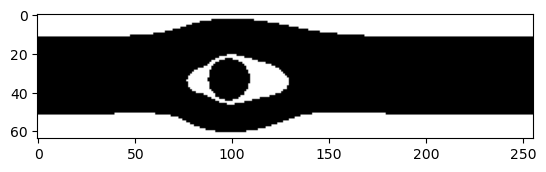

In [28]:
plt.imshow(y,cmap='gray')

In [29]:
yy=1-y

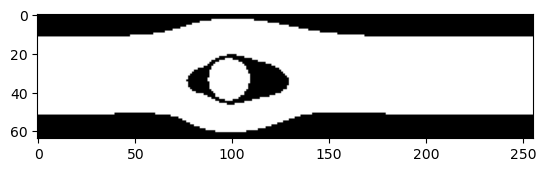

In [30]:
plt.imshow(yy,cmap='gray')

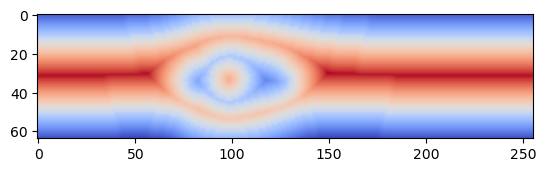

In [31]:
distance_outside = distance_transform_edt(yy)

distance_inside = distance_transform_edt(y)

sdf = distance_outside - distance_inside

plt.imshow(sdf, cmap='coolwarm')

In [32]:
n=sdf/255.

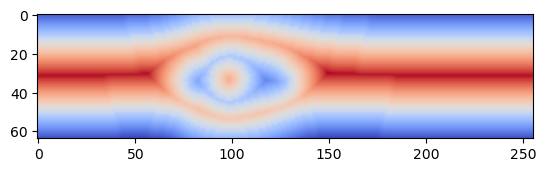

In [33]:
plt.imshow(n, cmap='coolwarm')

In [ ]:


# 1. Cargar y binarizar la imagen
# Supongamos que 'image_path' es la ruta a tu imagen
# y que la forma de interés es blanca sobre fondo negro.
# image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# _, binary_image = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)
# # Normalizar a 0 y 1 (0 para fondo, 1 para la forma)
# binary_image_norm = binary_image / 255.0

# --- Ejemplo creando una imagen binaria sintética ---
binary_image_norm = np.zeros((100, 100), dtype=np.float32)
binary_image_norm[30:70, 30:70] = 1.0 # Un cuadrado como forma
# ----------------------------------------------------


# 2. Calcular transformadas de distancia
# Distancia desde fuera de la forma al borde más cercano
# Invertimos la imagen: la forma es 0, el fondo es 1
inverted_binary_image = 1 - binary_image_norm
distance_outside = distance_transform_edt(inverted_binary_image)

# Distancia desde dentro de la forma al borde más cercano
# (los puntos de la forma tienen valor 1)
distance_inside = distance_transform_edt(binary_image_norm)

# 3. Combinar para obtener el SDF
# El SDF es positivo fuera, negativo dentro
sdf = distance_outside - distance_inside

# Los puntos exactamente en el borde podrían necesitar un manejo especial si se requiere un 0 exacto.
# Por ejemplo, podrías encontrar los contornos y poner esos píxeles a 0 en el sdf.

# Visualización (opcional)
# import matplotlib.pyplot as plt
# plt.imshow(sdf, cmap='coolwarm')
# plt.colorbar(label="Distancia con Signo")
# plt.title("Campo de Distancia con Signo (SDF)")
# plt.show()
